# TCGA Pan-Cancer — Exploratory Data Analysis

This notebook inspects the raw TCGA expression, mutation, and phenotype files downloaded from UCSC Xena.
Goal: understand the data format, TP53 mutation distribution, expression value ranges, and how TCGA compares to CCLE before building a pipeline.

In [1]:
from pathlib import Path
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
os.chdir(ROOT)

pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 30)

## 1. Raw File Overview

Load each file and inspect its shape and first few rows.

In [2]:
expr_raw = pd.read_csv('data/raw/tcga_expression.tsv.gz', sep='\t', index_col=0)
print('Expression matrix (raw):', expr_raw.shape, '→ rows=genes, cols=samples')
expr_raw.iloc[:5, :6]

Expression matrix (raw): (20531, 11069) → rows=genes, cols=samples


,TCGA-OR-A5J1-01,TCGA-OR-A5J2-01,TCGA-OR-A5J3-01,TCGA-OR-A5J5-01,TCGA-OR-A5J6-01,TCGA-OR-A5J7-01
sample,,,,,,
100130426,0.00,0.00,0.00,0.00,0.00,0.00
100133144,2.09,1.88,1.45,0.00,0.00,1.12
100134869,2.30,3.32,2.92,1.35,2.45,2.82
10357,7.23,6.36,6.45,5.78,6.09,6.71
10431,10.99,10.35,10.04,11.20,10.30,10.87


In [3]:
mut_raw = pd.read_csv('data/raw/tcga_mutations.tsv.gz', sep='\t')
print('Mutations table:', mut_raw.shape)
mut_raw.head()

Mutations table: (2907335, 12)


,sample,chr,start,end,reference,alt,gene,effect,Amino_Acid_Change,DNA_VAF,SIFT,PolyPhen
0,TCGA-02-0003-01,10,123810032,123810032,C,T,TACC2,Missense_Mutation,p.T38M,0.88,NaN,benign(0.335)
1,TCGA-02-0003-01,10,133967449,133967449,C,T,JAKMIP3,Silent,p.D723D,0.79,NaN,NaN
2,TCGA-02-0003-01,11,124489539,124489539,G,A,PANX3,Missense_Mutation,p.R296Q,0.41,tolerated(0.37),benign(0.001)
3,TCGA-02-0003-01,11,47380512,47380512,G,T,SPI1,Missense_Mutation,p.P127T,0.50,tolerated(0.08),benign(0.093)
4,TCGA-02-0003-01,11,89868837,89868837,C,T,NAALAD2,Missense_Mutation,p.R65C,0.51,deleterious(0.01),benign(0.034)


In [4]:
phen = pd.read_csv('data/raw/tcga_phenotype.tsv.gz', sep='\t')
print('Phenotype table:', phen.shape)
phen.head()

Phenotype table: (12804, 4)


,sample,sample_type_id,sample_type,_primary_disease
0,TCGA-D3-A1QA-07,7.0,Additional Metastatic,skin cutaneous melanoma
1,TCGA-DE-A4MD-06,6.0,Metastatic,thyroid carcinoma
2,TCGA-J8-A3O2-06,6.0,Metastatic,thyroid carcinoma
3,TCGA-J8-A3YH-06,6.0,Metastatic,thyroid carcinoma
4,TCGA-EM-A2P1-06,6.0,Metastatic,thyroid carcinoma


## 2. Expression Format

The expression matrix is **genes × samples** (transposed vs what the pipeline expects).
Gene names are **Entrez IDs** (numbers), not gene symbols — this differs from CCLE which uses `SYMBOL (ENTREZ_ID)` format.
Values are log2-normalised counts (same scale as CCLE's log2(TPM+1)).

In [5]:
# Transpose so rows=samples, cols=genes (pipeline convention)
expr = expr_raw.T
expr.index.name = 'sample_id'
print('Expression (transposed):', expr.shape, '→ rows=samples, cols=genes')
expr.iloc[:5, :6]

Expression (transposed): (11069, 20531) → rows=samples, cols=genes


sample,100130426,100133144,100134869,10357,10431,136542
sample_id,,,,,,
TCGA-OR-A5J1-01,0.0,2.09,2.30,7.23,10.99,0.0
TCGA-OR-A5J2-01,0.0,1.88,3.32,6.36,10.35,0.0
TCGA-OR-A5J3-01,0.0,1.45,2.92,6.45,10.04,0.0
TCGA-OR-A5J5-01,0.0,0.00,1.35,5.78,11.20,0.0
TCGA-OR-A5J6-01,0.0,0.00,2.45,6.09,10.30,0.0


## 3. Sample Types

TCGA contains primary tumors, normal tissue, metastatic samples, etc.
For a clean comparison with CCLE (cancer cell lines) we should keep only **Primary Tumor** samples.

In [6]:
phen['sample_type'].value_counts().rename('count').to_frame()

,count
sample_type,
Primary Tumor,10593
Solid Tissue Normal,1475
Metastatic,396
Primary Blood Derived Cancer - Peripheral Blood,200
Recurrent Tumor,56
Additional - New Primary,11
Additional Metastatic,1


In [7]:
primary = phen[phen['sample_type'] == 'Primary Tumor']
print('Primary tumor samples:', len(primary))
primary['_primary_disease'].value_counts().head(20)

Primary tumor samples: 10593


_primary_disease
breast invasive carcinoma                1101
glioblastoma multiforme                   594
ovarian serous cystadenocarcinoma         592
uterine corpus endometrioid carcinoma     547
kidney clear cell carcinoma               536
head & neck squamous cell carcinoma       528
lung adenocarcinoma                       520
brain lower grade glioma                  516
thyroid carcinoma                         507
lung squamous cell carcinoma              506
prostate adenocarcinoma                   498
stomach adenocarcinoma                    478
colon adenocarcinoma                      461
bladder urothelial carcinoma              412
liver hepatocellular carcinoma            377
cervical & endocervical cancer            308
kidney papillary cell carcinoma           291
sarcoma                                   261
pancreatic adenocarcinoma                 185
esophageal carcinoma                      185
Name: count, dtype: int64

## 4. TP53 Mutations

Extract TP53 entries from the mutation table and look at the effect (variant classification) distribution.

In [8]:
tp53_mut = mut_raw[mut_raw['gene'] == 'TP53'].copy()
print('TP53 mutation rows:', len(tp53_mut))
print('Unique samples with TP53 mutation:', tp53_mut['sample'].nunique())
tp53_mut.head()

TP53 mutation rows: 3729
Unique samples with TP53 mutation: 3325


,sample,chr,start,end,reference,alt,gene,effect,Amino_Acid_Change,DNA_VAF,SIFT,PolyPhen
19,TCGA-02-0003-01,17,7577094,7577094,G,A,TP53,Missense_Mutation,p.R282W,0.43,deleterious(0),probably_damaging(0.997)
20,TCGA-02-0003-01,17,7578396,7578396,G,T,TP53,Missense_Mutation,p.H178Q,0.38,deleterious(0),probably_damaging(1)
80,TCGA-02-0033-01,17,7577538,7577538,C,T,TP53,Missense_Mutation,p.R248Q,0.26,deleterious(0),probably_damaging(1)
211,TCGA-02-0055-01,17,7578203,7578203,C,T,TP53,Missense_Mutation,p.V216M,0.61,deleterious(0),probably_damaging(1)
363,TCGA-02-2483-01,17,7577120,7577120,C,T,TP53,Missense_Mutation,p.R273H,0.90,tolerated(0.13),possibly_damaging(0.631)


In [9]:
effect_counts = tp53_mut['effect'].value_counts().rename('count').to_frame()
effect_counts['percentage'] = (effect_counts['count'] / effect_counts['count'].sum() * 100).round(2)
effect_counts

,count,percentage
effect,,
Missense_Mutation,2382,63.88
Nonsense_Mutation,488,13.09
Frame_Shift_Del,332,8.90
Splice_Site,238,6.38
Frame_Shift_Ins,101,2.71
Silent,90,2.41
In_Frame_Del,68,1.82
In_Frame_Ins,11,0.29
Intron,8,0.21


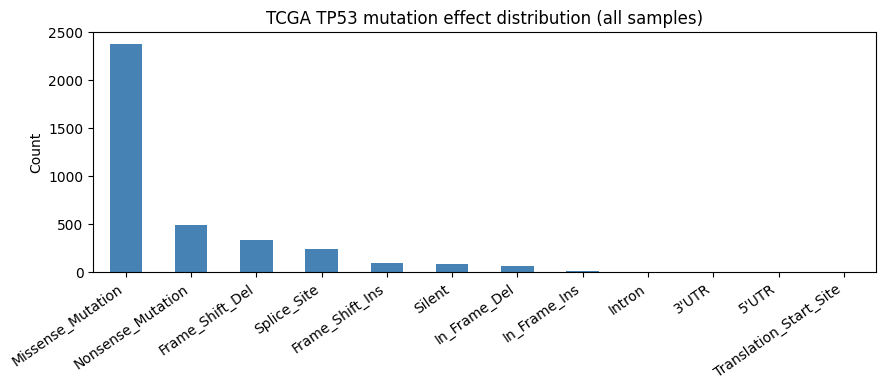

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
effect_counts['count'].plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('TCGA TP53 mutation effect distribution (all samples)')
ax.set_xlabel('')
ax.set_ylabel('Count')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

## 5. TCGA vs CCLE — Class Balance Comparison

How does the mutation type distribution compare to CCLE?

In [11]:
ccle_balance = pd.read_csv('data/processed/tp53_labels.csv')

# Map TCGA effect names to CCLE collapsed categories
effect_map = {
    'Missense_Mutation': 'Missense',
    'Nonsense_Mutation': 'Nonsense',
    'Frame_Shift_Del':   'Frameshift',
    'Frame_Shift_Ins':   'Frameshift',
    'Splice_Site':       'Splice',
    'Silent':            'Synonymous',
    'In_Frame_Del':      'In-frame indel',
    'In_Frame_Ins':      'In-frame indel',
}
tp53_mut['mutation_type_collapsed'] = tp53_mut['effect'].map(effect_map).fillna('Other')

tcga_counts = tp53_mut['mutation_type_collapsed'].value_counts().rename('TCGA (mutant samples)')
ccle_counts = ccle_balance[ccle_balance['tp53_mutant'] == 1]['mutation_type_collapsed'].value_counts().rename('CCLE (mutant samples)')

comparison = pd.concat([tcga_counts, ccle_counts], axis=1).fillna(0).astype(int)
comparison

,TCGA (mutant samples),CCLE (mutant samples)
mutation_type_collapsed,,
Missense,2382,620
Nonsense,488,113
Frameshift,433,58
Splice,238,0
Synonymous,90,8
In-frame indel,79,9
Other,19,189


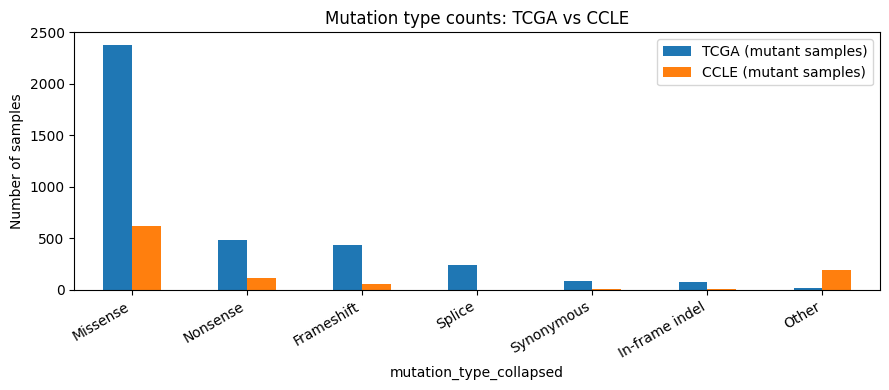

In [12]:
comparison.plot(kind='bar', figsize=(9, 4))
plt.title('Mutation type counts: TCGA vs CCLE')
plt.ylabel('Number of samples')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 6. Expression Value Distribution

Are TCGA expression values on the same scale as CCLE (log2-normalised)?

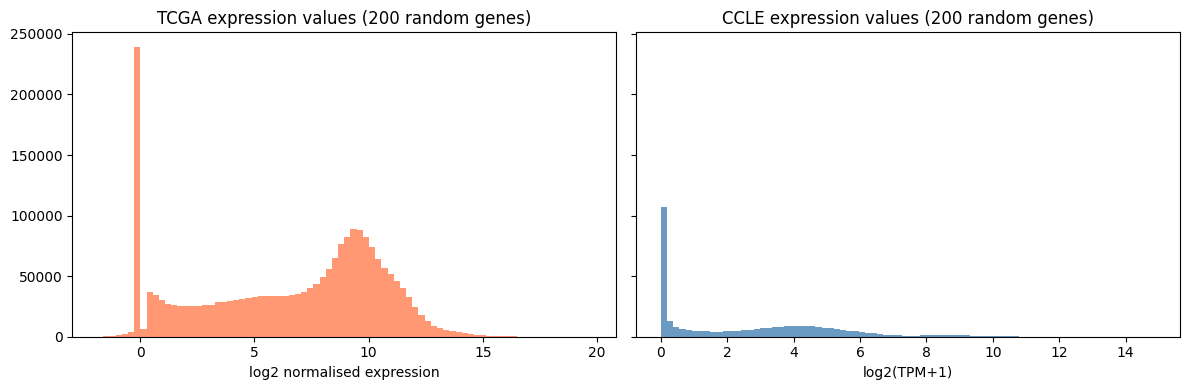

TCGA  — mean: 6.550, median: 7.600
CCLE  — mean: 2.608, median: 2.299


In [13]:
import numpy as np

# Sample 200 random genes from each dataset for speed
rng = np.random.default_rng(42)
tcga_sample = expr.iloc[:, rng.choice(expr.shape[1], 200, replace=False)].values.flatten()

ccle_expr = pd.read_csv('data/processed/expression_matched.csv.gz', index_col=0)
ccle_sample = ccle_expr.iloc[:, rng.choice(ccle_expr.shape[1], 200, replace=False)].values.flatten()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].hist(tcga_sample[np.isfinite(tcga_sample)], bins=80, color='coral', alpha=0.8)
axes[0].set_title('TCGA expression values (200 random genes)')
axes[0].set_xlabel('log2 normalised expression')
axes[1].hist(ccle_sample[np.isfinite(ccle_sample)], bins=80, color='steelblue', alpha=0.8)
axes[1].set_title('CCLE expression values (200 random genes)')
axes[1].set_xlabel('log2(TPM+1)')
plt.tight_layout()
plt.show()

print(f'TCGA  — mean: {tcga_sample[np.isfinite(tcga_sample)].mean():.3f}, median: {np.median(tcga_sample[np.isfinite(tcga_sample)]):.3f}')
print(f'CCLE  — mean: {ccle_sample[np.isfinite(ccle_sample)].mean():.3f}, median: {np.median(ccle_sample[np.isfinite(ccle_sample)]):.3f}')

## 7. Sample Overlap & Matching

How many expression samples also have mutation data (required for labelling)?

In [14]:
expr_samples   = set(expr.index)
mut_samples    = set(tp53_mut['sample'])
phen_samples   = set(primary['sample'])

# Samples present in expression AND phenotype (primary tumor)
expr_primary   = expr_samples & phen_samples

print(f'Expression samples total:          {len(expr_samples):>6}')
print(f'Primary tumor phenotype samples:   {len(phen_samples):>6}')
print(f'Expression ∩ primary tumor:        {len(expr_primary):>6}')
print(f'Of those, with TP53 mutation:      {len(expr_primary & mut_samples):>6}')
print(f'Of those, TP53 wild-type:          {len(expr_primary - mut_samples):>6}')

Expression samples total:           11069
Primary tumor phenotype samples:    10593
Expression ∩ primary tumor:          9701
Of those, with TP53 mutation:        3130
Of those, TP53 wild-type:            6571


## 8. Key Observations

Summarise what we've learned before building the pipeline.

In [15]:
rows = [
    ('Total expression samples', len(expr_samples)),
    ('Primary tumor samples (after filter)', len(expr_primary)),
    ('TP53 mutant (primary tumor)', len(expr_primary & mut_samples)),
    ('TP53 wild-type (primary tumor)', len(expr_primary - mut_samples)),
    ('Number of genes', expr.shape[1]),
]
pd.DataFrame(rows, columns=['metric', 'value'])

,metric,value
0,Total expression samples,11069
1,Primary tumor samples (after filter),9701
2,TP53 mutant (primary tumor),3130
3,TP53 wild-type (primary tumor),6571
4,Number of genes,20531


## 9. Interpretation & Pipeline Implications

### Summary table

| | TCGA | CCLE |
|---|---|---|
| Total samples (after filter) | 9,701 | 1,719 |
| TP53 mutant | 3,130 (32%) | 997 (58%) |
| TP53 wild-type | 6,571 (68%) | 722 (42%) |
| Genes | 20,531 | 19,215 |
| Expression mean | 6.55 | 2.61 |

---

### 1. Expression scale mismatch — critical
TCGA values have a mean of **6.55** vs CCLE's **2.61** — roughly 2.5× higher. They use different underlying normalisation (TCGA: RSEM, CCLE: TPM). **They cannot be mixed or directly compared without re-normalisation.** For this project we will treat TCGA as a standalone dataset, because even if we use re-normalisation, the truth is that TCGA consists of patient cancer cells, which are noisier than immortalized cell lines (CCLE).

### 2. Gene names need mapping
TCGA uses raw **Entrez IDs** as column names (e.g.  for TP53). CCLE uses  format. The pipeline's  and  use gene symbols (, , etc.). A mapping step is required to convert Entrez IDs → gene symbols before the curated gene set selectors will work.

### 3. Multiclass task is now much more tractable
The rare mutation classes are 4–7× more represented in TCGA:

| Class | CCLE | TCGA | Fold change |
|---|---|---|---|
| Missense | 620 | 2,382 | +4× |
| Nonsense | 113 | 488 | +4× |
| Frameshift | 58 | 433 | +7.5× |
| Splice | 0 | 238 | new class |

With TCGA, **Splice site** mutations can be added as a 5th prediction class (previously absent from CCLE entirely).

### 4. Binary task: class imbalance flipped
In CCLE, mutants were the majority (58%). In TCGA, wild-type is the majority (68%). The class-weighted models already used in the pipeline handle this, but the baseline accuracy shifts accordingly.

### 5. What needs to change in the pipeline
- **New build script** (): transpose expression, map Entrez IDs → gene symbols, extract TP53 labels from the  column using TCGA naming, filter to Primary Tumor only.
- **Label mapping**:  → ,  → ,  → ,  → .
- **No model or evaluation changes needed**: , , and  are dataset-agnostic and reusable as-is.
